In [1]:
# Load convolve_im_freq from freq_1.ipynb 
from IPython.display import clear_output
%run -n freq_1.ipynb 
clear_output(wait=False) 

import os
import numpy as np
import utils
import matplotlib.pyplot as plt 

In [2]:
def create_kernel(im):
    """
    Creates a notch filter kernel in the frequency domain to remove periodic noise.
    
    Args:
        im: np.array of shape [H, W]
    Returns:
        kernel: np.array of shape [H, W]
    """
    # Initialize the kernel with ones (pass-through filter)
    kernel = np.ones_like(im)
    
    # Get image dimensions and compute FFT shift
    H, W = im.shape
    center_h, center_w = H // 2, W // 2
    
    # Define the notch positions based on observed noise frequencies in the FFT
    # Example: (offsets relative to the center)
    noise_positions = [(center_h + 20, center_w + 20), (center_h - 20, center_w - 20)]
    
    # Define the radius of the notch (tunable depending on noise spread)
    radius = 10  # Example radius, adjust as needed
    
    # Apply notch filter at specified noise positions
    for (y, x) in noise_positions:
        y_min, y_max = max(0, y - radius), min(H, y + radius)
        x_min, x_max = max(0, x - radius), min(W, x + radius)
        kernel[y_min:y_max, x_min:x_max] = 0
    
    return kernel

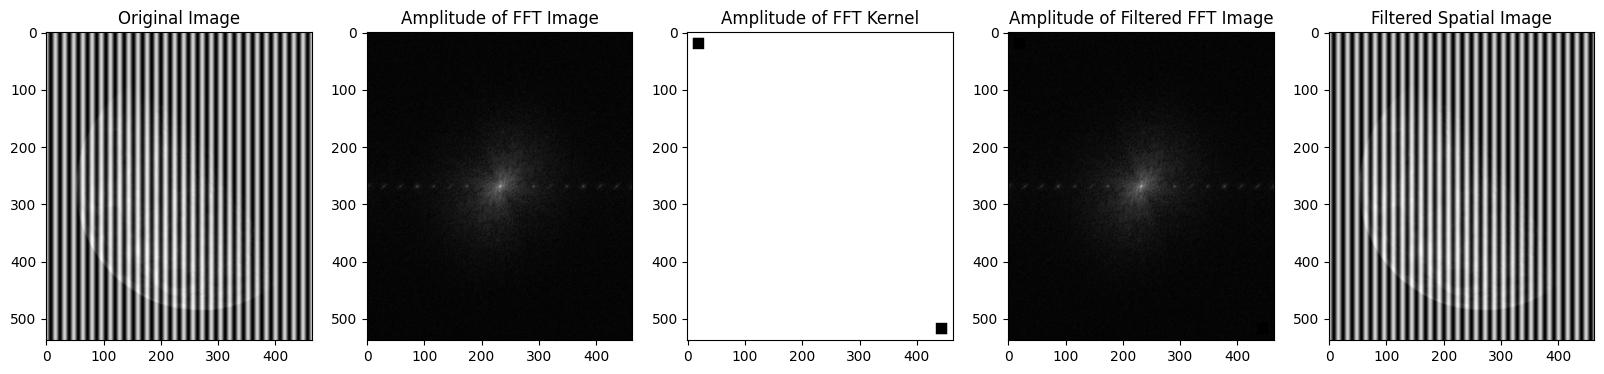

Saving image to: image_processed/moon_filtered.png


In [3]:
if __name__ == "__main__":
    # Changing this code should not be needed!
    
    impath = os.path.join("images", "noisy_moon.png")
    im = utils.read_im(impath)

    kernel = create_kernel(im)        
    # Note that this function is from your own implementation of convolve_im_freq from freq_1.ipynb
    im_filtered = convolve_im_freq(im, kernel, True) 
    
    utils.save_im("moon_filtered.png", utils.normalize(im_filtered))